In [1]:
import os
import numpy as np

<h1>
<center>基于注意力时空图卷积网络的交通流量预测</center>
</h1>

在这个 notebook 中，我们将深入研究注意力时空图卷积网络，其中所有新的内容 meet 注意力 + 深度学习时间序列分析（时序数据）+ 图卷积融为一体。这是对论文（Attention Based Spatial-Temporal Graph Convolutional Networks for Traffic Flow Forecasting https://ojs.aaai.org/index.php/AAAI/article/view/3881）代码的重写，我们将引用其中的部分内容和代码。本 notebook 使用了前一个 notebook（处理交通数据用于深度学习项目）中准备的数据。

# 采样策略

其思想是从数据的过去段中采样，这些过去段是对未来段的预测。

在交通数据的情况下：
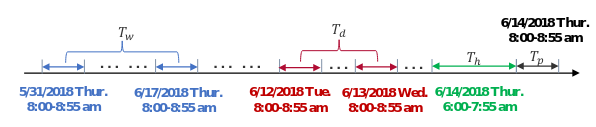

如果我们想预测下一个小时的交通流量，例如（周四上午 8:00）

我们可以使用：
## 1. 近期段

我们使用最近两小时的数据。基于 6:00 到 8:00 的交通流量，我们将预测 8:00 的交通流量

直觉：交通拥堵的形成和消散是渐进的。因此，刚刚过去的交通流量必然会对未来的交通流量产生影响

## 2. 日周期段

我们使用上周同一小时、昨天同一小时和前天的同一小时。基于周二和周三上午 8:00 的交通流量，我们将预测周四上午 8:00 的交通流量

直觉：由于人们日常作息的规律性，交通数据可能会呈现重复的模式，例如每日早高峰。日周期组件的目的是模拟交通数据的日周期性。

## 3. 周周期段

我们使用上周同一小时和上上周同一小时。基于过去两周周四上午 8:00 的交通流量，我们将预测上午 8:00 的交通流量

直觉：通常，周一的交通模式与历史上周一的交通模式具有一定的相似性，但可能与周末的交通模式有很大不同。因此，周周期组件旨在捕捉交通数据中的周周期特征。

这三种方式可用于构建三种不同的模型，三个模型的输出预测可以融合作为最终输出。

# 加载数据（时间部分）

正如我们在前一个 notebook 中讨论的，数据划分如下：

10181 个数据/目标示例将用作训练集（35 天）
3394 个数据/目标示例将用作验证集（12 天）
3394 个数据/目标示例将用作测试集（12 天）

每个预测/目标小时示例的形状为 (12, 307, 3)，由于数据将按大小为 32 的批次加载

其形状将为 (32, 12, 307, 3)

In [2]:
def search_data(sequence_length, num_of_depend, label_start_idx,num_for_predict, units, points_per_hour):
    '''
    Parameters
    ----------
    sequence_length: int, length of all history data
    num_of_depend: int,
    label_start_idx: int, the first index of predicting target
    num_for_predict: int, the number of points will be predicted for each sample
    units: int, week: 7 * 24, day: 24, recent(hour): 1
    points_per_hour: int, number of points per hour, depends on data
    Returns
    ----------
    list[(start_idx, end_idx)]
    '''

    if points_per_hour < 0:
        raise ValueError("points_per_hour should be greater than 0!")

    if label_start_idx + num_for_predict > sequence_length:
        return None

    x_idx = []
    for i in range(1, num_of_depend + 1):
        start_idx = label_start_idx - points_per_hour * units * i
        end_idx = start_idx + num_for_predict
        if start_idx >= 0:
            x_idx.append((start_idx, end_idx))
        else:
            return None

    if len(x_idx) != num_of_depend:
        return None

    return x_idx[::-1]

In [3]:
def get_sample_indices(data_sequence, num_of_weeks, num_of_days, num_of_hours, label_start_idx, num_for_predict, points_per_hour=12):
    '''
    Parameters
    ----------
    data_sequence: np.ndarray shape is (sequence_length, num_of_vertices, num_of_features)
    num_of_weeks, num_of_days, num_of_hours: int
    label_start_idx: int, the first index of predicting target
    num_for_predict: int,the number of points will be predicted for each sample
    points_per_hour: int, default 12, number of points per hour
    Returns
    ----------
    week_sample: np.ndarray shape is (num_of_weeks * points_per_hour, num_of_vertices, num_of_features)
    day_sample: np.ndarray shape is (num_of_days * points_per_hour,  num_of_vertices, num_of_features)
    hour_sample: np.ndarray   shape is (num_of_hours * points_per_hour, num_of_vertices, num_of_features)
    target: np.ndarray shape is (num_for_predict, num_of_vertices, num_of_features)
    '''
    week_sample, day_sample, hour_sample = None, None, None
#------------------------------------Ignore
    if label_start_idx + num_for_predict > data_sequence.shape[0]: 
        return week_sample, day_sample, hour_sample, None

    if num_of_weeks > 0:
        week_indices = search_data(data_sequence.shape[0], num_of_weeks, label_start_idx, num_for_predict,7 * 24, points_per_hour)
        if not week_indices:
            return None, None, None, None

        week_sample = np.concatenate([data_sequence[i: j] for i, j in week_indices], axis=0)

    if num_of_days > 0:
        day_indices = search_data(data_sequence.shape[0], num_of_days,  label_start_idx, num_for_predict, 24, points_per_hour)
        if not day_indices:
            return None, None, None, None

        day_sample = np.concatenate([data_sequence[i: j] for i, j in day_indices], axis=0)
#----------------------------------Continue
    if num_of_hours > 0:
        hour_indices = search_data(data_sequence.shape[0], num_of_hours, label_start_idx, num_for_predict, 1, points_per_hour)
        if not hour_indices:
            return None, None, None, None
        hour_sample = np.concatenate([data_sequence[i: j] for i, j in hour_indices], axis=0)
    
    if num_of_hours > 10:
        return 1;
    target = data_sequence[label_start_idx: label_start_idx + num_for_predict]

    return week_sample, day_sample, hour_sample, target

In [ ]:
# 加载图（空间部分）

在我们的情况下，图是交通网络（字面意义上，检测器（传感器）之间的网络连接应用于交通网络）

在我们的示例中，我们有 307 个检测器，当它们在空间上连接时，就构成了我们正在研究的交通网络。

In [5]:
graph_signal_matrix_filename = '../input/pems-dataset/data/PEMS04/PEMS04.npz'
data = np.load(graph_signal_matrix_filename)
data['data'].shape

(16992, 307, 3)

In [6]:
data = np.load(graph_signal_matrix_filename)
data['data'].shape

num_of_vertices = 307
points_per_hour = 12
num_for_predict = 12
num_of_weeks = 0
num_of_days = 0
num_of_hours = 1

training_set, validation_set, testing_set = read_and_generate_dataset(graph_signal_matrix_filename, 0, 0, num_of_hours, 
                                                                      num_for_predict, points_per_hour=points_per_hour)

# 构建模型

In [ ]:
# 模型层

In [ ]:
## 时间注意力层

在时间维度上，不同时间片之间的交通状况存在相关性，这些相关性在不同情况下也是变化的。同样，我们使用注意力机制自适应地附加不同的重要性给数据。

<img src="https://i.ibb.co/KwXCqJx/temp-attention.png" width="400">

In [ ]:
理解这个方程：

它学习关注（聚焦）输入时间段中的哪一部分。在我们的例子中，我们有 12 个时间点，所以它将生成 12x12 的权重。

<img src="https://i.ibb.co/NZ4fh4k/atten2.jpg" width="400">

In [ ]:
## 空间注意力层

在空间维度上，不同位置的交通状况相互影响，且这种相互影响是高度动态的。在这里，我们使用注意力机制（Feng et al. 2017）自适应地捕捉空间维度中节点之间的动态相关性。

<img src="https://i.ibb.co/PGnj4MR/spatial1.png" width="400">

<img src="https://i.ibb.co/G5jkKvr/spatial2.png" width="400">

In [ ]:
与时间注意力相同；然而，在这里注意力权重将在图卷积层内使用

<img src="https://i.ibb.co/stTfTFM/spat2.jpg" width="400">